# **HW4: k-Nearest Neighbors and Simple Linear Regression**

#### **Attention:** *This assignment is to be completed individually. Group work is not permitted.*

# **Machine Learning Fundamentals from Scratch**

In this homework exercise, we will implement two fundamental machine learning algorithms from scratch: **k-Nearest Neighbors (k-NN)** for classification and **Simple Linear Regression** for regression.

## **Part 1: k-Nearest Neighbors (k-NN)**

k-NN is an instance-based learning algorithm that classifies a data point based on the majority vote of its k nearest neighbors in the feature space.

**How it works:**
1. Calculate the distance between the test point and all training points
2. Select the k nearest training points
3. Assign the class that appears most frequently among these k neighbors

**Key characteristics:**
- Non-parametric (doesn't assume a specific form for the decision boundary)
- Requires storing all training data
- Sensitive to the choice of k and distance metric

## **Part 2: Simple Linear Regression**

Simple linear regression models the relationship between:
- **One input variable** (x) - also called the independent variable or feature
- **One output variable** (y) - also called the dependent variable or target

The model learns a linear equation:

**y = b₀ + b₁·x**

Where:
- **b₀** (bias/intercept): The value of y when x = 0
- **b₁** (slope/weight): How much y changes for each unit change in x

## **Objectives**

In this exercise, you will:
1. Load a binary classification dataset and implement k-NN from scratch
2. Evaluate k-NN performance on training and test sets
3. Create synthetic data and implement simple linear regression
4. Understand how noise affects the learned parameters

## **Import Libraries**

Let's start by importing the necessary libraries.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 6)

# Set random seed for reproducibility
np.random.seed(42)

print("Libraries imported successfully!")

Libraries imported successfully!


---
# **PART 1: k-Nearest Neighbors Classification**
---

## **Load and Explore the Dataset**

Load the Breast Cancer Wisconsin dataset from scikit-learn. This is a binary classification dataset where the goal is to predict whether a tumor is malignant (cancerous) or benign (non-cancerous).

The dataset contains:
- **569 samples**
- **30 features** computed from digitized images of breast mass
- **2 classes**: 0 (malignant) and 1 (benign)

After loading the data:
1. Print the shape of X and y
2. Print the feature names
3. Print the class distribution (how many samples in each class)

In [2]:
# Load the dataset
data = load_breast_cancer()
X, y = data.data, data.target

# Print dataset information
print("Dataset loaded successfully!")
print("="*60)
print(f"\nDataset shape:")
print(f"  X (features): {X.shape}")
print(f"  y (labels):   {y.shape}")

print(f"\nFeature names ({len(data.feature_names)} features):")
for i, name in enumerate(data.feature_names[:10]):  # Show first 10
    print(f"  {i}: {name}")
print("  ...")

print(f"\nClass distribution:")
unique, counts = np.unique(y, return_counts=True)
for label, count in zip(unique, counts):
    class_name = data.target_names[label]
    print(f"  Class {label} ({class_name}): {count} samples ({count/len(y)*100:.1f}%)")

print(f"\nTarget names: {data.target_names}")
print("Note: 0 = malignant (cancerous), 1 = benign (non-cancerous)")

Dataset loaded successfully!

Dataset shape:
  X (features): (569, 30)
  y (labels):   (569,)

Feature names (30 features):
  0: mean radius
  1: mean texture
  2: mean perimeter
  3: mean area
  4: mean smoothness
  5: mean compactness
  6: mean concavity
  7: mean concave points
  8: mean symmetry
  9: mean fractal dimension
  ...

Class distribution:
  Class 0 (malignant): 212 samples (37.3%)
  Class 1 (benign): 357 samples (62.7%)

Target names: ['malignant' 'benign']
Note: 0 = malignant (cancerous), 1 = benign (non-cancerous)


## **TASK 1: Visualize the Data**

Create two visualizations:

1. **Plot the distribution of labels** (class distribution bar chart)
2. **Plot the distribution of the first 4 features** as histograms, colored by class label

This will help you understand the data before building models.

**Hint**: For the feature distributions, create a 2x2 subplot grid showing histograms for the first 4 features, with different colors for each class.

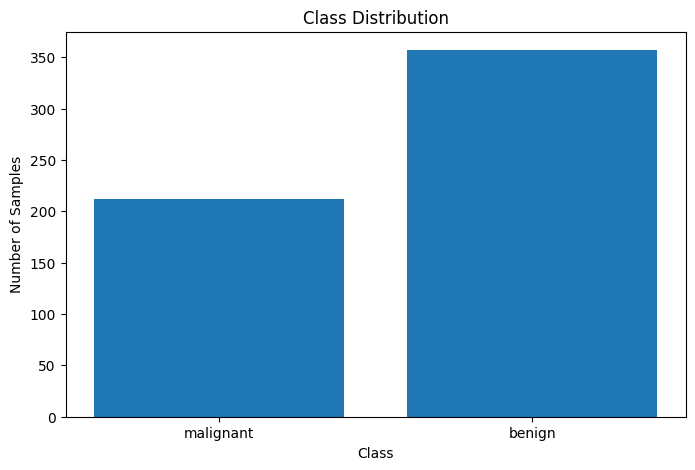

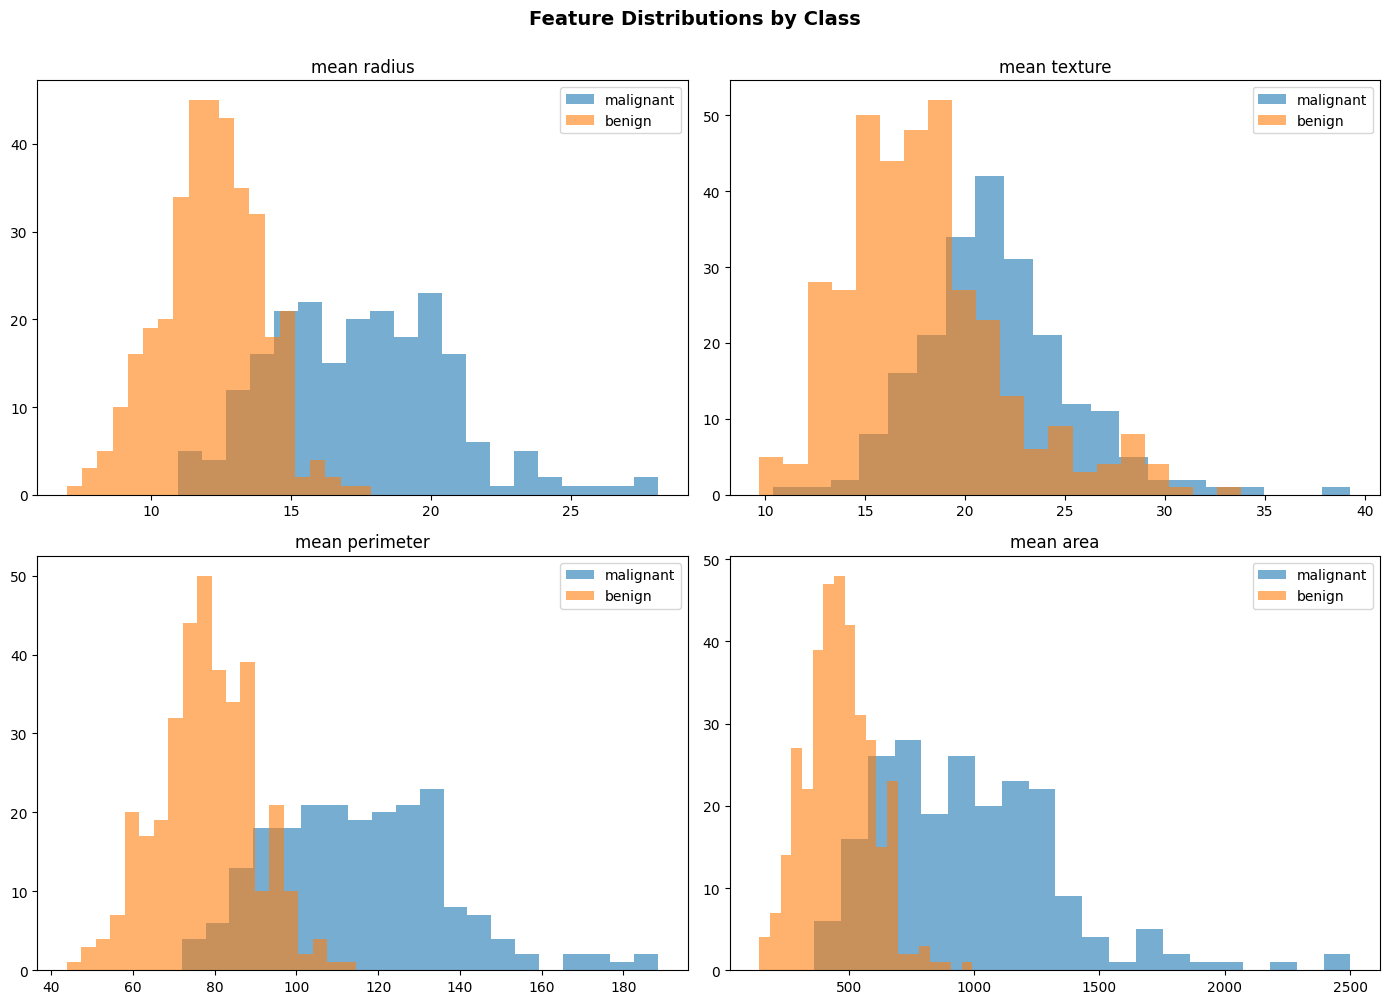

Observation: Notice how some features show clear separation between classes,
while others have more overlap. This affects how well our models can classify.


In [3]:
# Write your code here

# 1. Plot class distribution
plt.figure(figsize=(8, 5))
unique, counts = np.unique(y, return_counts=True)
plt.bar(data.target_names, counts)
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Samples")
plt.show()

# 2. Plot distributions of first 4 features
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for i in range(4):
    # Plot histogram for each class
    for label in np.unique(y):
        axes[i].hist(
            X[y == label, i],
            bins=20,
            alpha=0.6,
            label=data.target_names[label]
        )
    
    axes[i].set_title(data.feature_names[i])
    axes[i].legend()

plt.suptitle('Feature Distributions by Class', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

print("Observation: Notice how some features show clear separation between classes,")
print("while others have more overlap. This affects how well our models can classify.")

## **TASK 2: Split and Standardize the Data**

Before training our models:

1. **Split the data** into training (75%) and testing (25%) sets using `train_test_split`
   - Use `random_state=42` for reproducibility
2. **Standardize the features** using `StandardScaler`
   - Fit the scaler on training data only
   - Transform both training and testing data
3. Print the shapes of the resulting datasets

**Why standardize?**
- k-NN uses distances, so features with larger scales will dominate
- Ensures all features contribute equally to the model

In [4]:
# Write your code here

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

print("Data split successfully!")
print(f"Training set: {X_train.shape[0]} samples")
print(f"Testing set:  {X_test.shape[0]} samples")

# Standardize the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("\nFeatures standardized!")
print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape:  {X_test.shape}")
print(f"\nFeature statistics after standardization (train set):")
print(f"  Mean: {np.mean(X_train, axis=0)[0]:.6f} (should be ~0)")
print(f"  Std:  {np.std(X_train, axis=0)[0]:.6f} (should be ~1)")

Data split successfully!
Training set: 426 samples
Testing set:  143 samples

Features standardized!
Training set shape: (426, 30)
Testing set shape:  (143, 30)

Feature statistics after standardization (train set):
  Mean: -0.000000 (should be ~0)
  Std:  1.000000 (should be ~1)


## **TASK 3: Implement k-NN from Scratch**

Implement the following functions for k-NN classification:

1. **`euclidean_distance(point1, point2)`**: Calculate the Euclidean distance between two points
   - Formula: √(Σ(point1ᵢ - point2ᵢ)²)

2. **`get_k_nearest_neighbors(X_train, test_point, k)`**: Find the indices of k nearest neighbors
   - Calculate distances from test_point to all training points
   - Return indices of k points with smallest distances

3. **`predict_knn(X_train, y_train, test_point, k)`**: Predict class for a single test point
   - Get k nearest neighbors
   - Return the most common class among them (majority vote)

4. **`knn_classifier(X_train, y_train, X_test, k)`**: Predict classes for all test points
   - Apply predict_knn to each test point
   - Return array of predictions

In [ ]:
# Write your code here

def euclidean_distance(point1, point2):
    """
    Calculate the Euclidean distance between two points in n-dimensional space.
    
    Parameters:
    -----------
    point1 : numpy array
        First point
    point2 : numpy array
        Second point
    
    Returns:
    --------
    float
        Euclidean distance between the two points
    """
    return np.sqrt(np.sum((point1 - point2) ** 2))


def get_k_nearest_neighbors(X_train, test_point, k):
    """
    Find the indices of k nearest neighbors to a test point.
    
    Parameters:
    -----------
    X_train : numpy array
        Training feature matrix
    test_point : numpy array
        Single test point
    k : int
        Number of neighbors to find
    
    Returns:
    --------
    numpy array
        Indices of k nearest neighbors
    """
    distances = []

    for i in range(len(X_train)):
        dist = euclidean_distance(test_point, X_train[i])
        distances.append((i, dist))

    distances.sort(key=lambda x: x[1])
    neighbors = [distances[i][0] for i in range(k)]
    return neighbors



def predict_knn(X_train, y_train, test_point, k):
    """
    Predict the class of a test point using k-NN.
    
    Parameters:
    -----------
    X_train : numpy array
        Training feature matrix
    y_train : numpy array
        Training labels
    test_point : numpy array
        Single test point
    k : int
        Number of neighbors to consider
    
    Returns:
    --------
    int
        Predicted class label
    """
    neighbors = get_k_nearest_neighbors(X_train, test_point, k)
    labels = [y_train[i] for i in neighbors]
    return max(set(labels), key=labels.count)



def knn_classifier(X_train, y_train, X_test, k):
    """
    Classify all test points using k-NN.
    
    Parameters:
    -----------
    X_train : numpy array
        Training feature matrix
    y_train : numpy array
        Training labels
    X_test : numpy array
        Test feature matrix
    k : int
        Number of neighbors to consider
    
    Returns:
    --------
    numpy array
        Predicted labels for all test points
    """
    predictions = []

    for point in X_test:
        pred = predict_knn(X_train, y_train, point, k)
        predictions.append(pred)
    return np.array(predictions)



print("k-NN functions implemented successfully!")

k-NN functions implemented successfully!


## **Evaluate k-NN Performance**

Test your k-NN implementation with k=5:

1. Calculate predictions on the **training set**
2. Calculate predictions on the **test set**
3. Compute and print the training accuracy
4. Compute and print the test accuracy

**Accuracy formula:** (Number of correct predictions) / (Total number of predictions)


In [6]:
k = 5

print(f"Evaluating k-NN with k={k}...")
print("="*60)

# Get predictions on training set
y_train_pred = knn_classifier(X_train, y_train, X_train, k)
train_accuracy = np.mean(y_train_pred == y_train)

# Get predictions on test set
y_test_pred_knn = knn_classifier(X_train, y_train, X_test, k)
test_accuracy = np.mean(y_test_pred_knn == y_test)

print(f"\nk-NN Performance (k={k}):")
print(f"  Training Accuracy: {train_accuracy:.4f} ({train_accuracy*100:.2f}%)")
print(f"  Test Accuracy:     {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"\nDifference: {(train_accuracy - test_accuracy)*100:.2f}%")

if train_accuracy > test_accuracy:
    print("\nNote: Training accuracy is higher than test accuracy, which is normal.")
    print("The model performs slightly better on data it has seen during training.")
else:
    print("\nNote: Test accuracy is similar to or higher than training accuracy.")
    print("This is a good sign - the model generalizes well!")

Evaluating k-NN with k=5...

k-NN Performance (k=5):
  Training Accuracy: 0.9789 (97.89%)
  Test Accuracy:     0.9580 (95.80%)

Difference: 2.08%

Note: Training accuracy is higher than test accuracy, which is normal.
The model performs slightly better on data it has seen during training.


---
# **PART 2: Simple Linear Regression**
---

## **Understanding Simple Linear Regression**

Simple linear regression is a fundamental machine learning technique that models the relationship between one input variable (x) and one output variable (y).

**The model equation:**

**y = b₀ + b₁·x**

**How Does It Learn?**

Linear regression finds the best values for b₀ and b₁ by **minimizing the Mean Squared Error (MSE)**:

**MSE = (1/n) Σ(yᵢ - ŷᵢ)²**

**Closed-Form Solution:**

For simple linear regression, we can derive the optimal parameters using calculus:

**b₁ = Σ((xᵢ - x̄)(yᵢ - ȳ)) / Σ((xᵢ - x̄)²)**

**b₀ = ȳ - b₁·x̄**

Where x̄ and ȳ are the mean values of x and y.

## **TASK 4: Create Synthetic Dataset**

Let's create a synthetic dataset where y has a perfect linear relationship with x:

**y = b₀ + b₁·x**

We'll use:
- **True b₀ (bias/intercept) = 2.0**
- **True b₁ (slope) = 3.0**
- **x values**: 1000 evenly spaced points from 0 to 10

This means the relationship is: **y = 2.0 + 3.0·x**

In [7]:
# Define true parameters
true_b0 = 2.0  # True bias/intercept
true_b1 = 3.0  # True slope

# Create x values: 1000 evenly spaced points from 0 to 10
x = np.linspace(0, 10, 1000)

# Write your code here

# Calculate y values using the true linear relationship
y_reg = true_b0 + true_b1 * x

print(f"Created dataset with {len(x)} points")
print(f"True parameters: b₀ = {true_b0}, b₁ = {true_b1}")
print(f"\nFirst 5 data points:")
for i in range(5):
    print(f"  x[{i}] = {x[i]:.2f}, y[{i}] = {y_reg[i]:.2f}")
print(f"\nLast 5 data points:")
for i in range(-5, 0):
    print(f"  x[{i}] = {x[i]:.2f}, y[{i}] = {y_reg[i]:.2f}")

Created dataset with 1000 points
True parameters: b₀ = 2.0, b₁ = 3.0

First 5 data points:
  x[0] = 0.00, y[0] = 2.00
  x[1] = 0.01, y[1] = 2.03
  x[2] = 0.02, y[2] = 2.06
  x[3] = 0.03, y[3] = 2.09
  x[4] = 0.04, y[4] = 2.12

Last 5 data points:
  x[-5] = 9.96, y[-5] = 31.88
  x[-4] = 9.97, y[-4] = 31.91
  x[-3] = 9.98, y[-3] = 31.94
  x[-2] = 9.99, y[-2] = 31.97
  x[-1] = 10.00, y[-1] = 32.00


## **TASK 5: Implement Linear Regression Solver**

Now implement a function that performs linear regression to learn b₀ and b₁ from data.

Your function should:
1. Take x and y arrays as input
2. Calculate the means of x and y
3. Use the closed-form formulas to compute b₁ and b₀
4. Return both parameters

**Formulas to implement:**

**b₁ = Σ((xᵢ - x̄)(yᵢ - ȳ)) / Σ((xᵢ - x̄)²)**

**b₀ = ȳ - b₁·x̄**

**Hint**: Use NumPy operations:
- `np.mean()` to calculate means
- `np.sum()` to calculate sums
- Element-wise operations work on arrays

In [8]:
def linear_regression(x, y):
    """
    Perform simple linear regression to find b0 and b1.
    
    Parameters:
    -----------
    x : numpy array
        Input features (1D array)
    y : numpy array
        Target values (1D array)
    
    Returns:
    --------
    b0 : float
        Learned bias/intercept
    b1 : float
        Learned slope/weight
    """
    x_bar = np.mean(x)
    y_bar = np.mean(y)

    b1 = np.sum((x - x_bar) * (y - y_bar)) / np.sum((x - x_bar) ** 2)
    b0 = y_bar - b1 * x_bar

    return b0, b1


print("Linear regression function defined successfully!")

Linear regression function defined successfully!


## **Learn Parameters**

Now call your `linear_regression()` function on the perfect dataset and verify that it recovers the true parameters.

Since the data has no noise, the learned parameters should exactly match the true values (within a small error tolerance):
- Learned b₀ should equal 2.0
- Learned b₁ should equal 3.0

In [9]:
# Write your code here

# Call the linear regression function
learned_b0, learned_b1 = linear_regression(x, y_reg)

print("Linear Regression Results on Perfect Data:")
print("="*50)
print(f"\nTrue parameters:")
print(f"  b₀ (intercept) = {true_b0}")
print(f"  b₁ (slope)     = {true_b1}")
print(f"\nLearned parameters:")
print(f"  b₀ (intercept) = {learned_b0:.10f}")
print(f"  b₁ (slope)     = {learned_b1:.10f}")
print(f"\nDifference (should be ~0):")
print(f"  Δb₀ = {abs(learned_b0 - true_b0):.2e}")
print(f"  Δb₁ = {abs(learned_b1 - true_b1):.2e}")

# Calculate predictions
y_pred = learned_b0 + learned_b1 * x

# Calculate MSE (should be essentially 0)
mse = np.mean((y_reg - y_pred) ** 2)
print(f"\nMean Squared Error: {mse:.2e}")
print("\n✓ Perfect match! The model recovered the exact parameters.")

Linear Regression Results on Perfect Data:

True parameters:
  b₀ (intercept) = 2.0
  b₁ (slope)     = 3.0

Learned parameters:
  b₀ (intercept) = 2.0000000000
  b₁ (slope)     = 3.0000000000

Difference (should be ~0):
  Δb₀ = 7.11e-15
  Δb₁ = 8.88e-16

Mean Squared Error: 1.36e-29

✓ Perfect match! The model recovered the exact parameters.


## **TASK 6: Visualize Fit**

Let's visualize the data points and the learned line.

Create a plot that shows:
- The data points as blue circles
- The learned regression line as a red line
- Appropriate labels and title

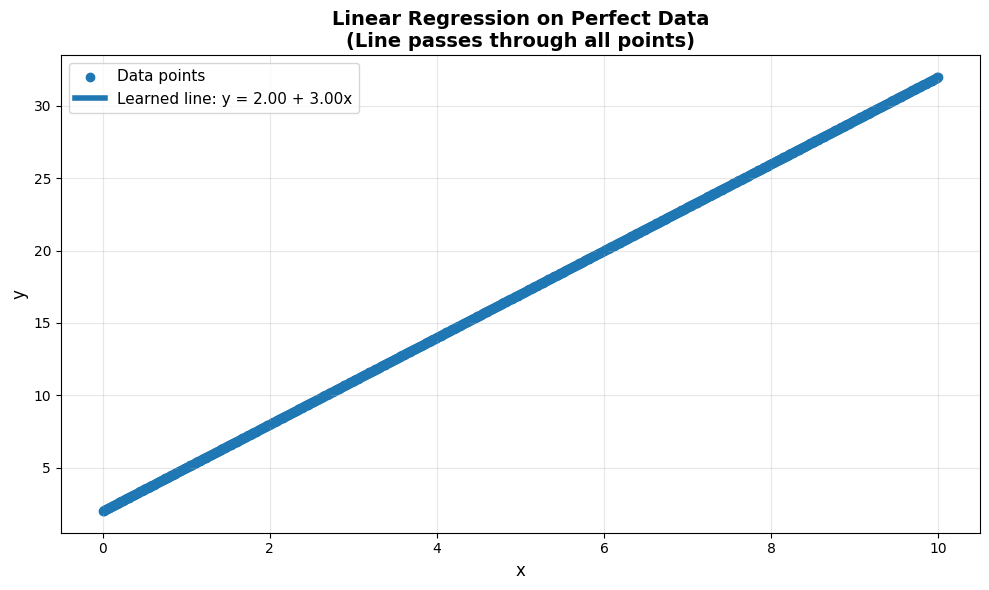

As expected, the line passes through all data points perfectly!
This is because there's no noise in the data.


In [22]:
# Write your code here

plt.figure(figsize=(10, 6))

# Plot data points
plt.scatter(x, y_reg, alpha=1.0, label="Data points")

# Plot learned regression line
b0_hat, b1_hat = linear_regression(x, y_reg)
y_pred = b0_hat + b1_hat * x
plt.plot(x, y_pred, linewidth=4, label=f"Learned line: y = {b0_hat:.2f} + {b1_hat:.2f}x")

plt.xlabel('x', fontsize=12)
plt.ylabel('y', fontsize=12)
plt.title('Linear Regression on Perfect Data\n(Line passes through all points)', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("As expected, the line passes through all data points perfectly!")
print("This is because there's no noise in the data.")

## **Task 7: QUESTION**

The line perfectly goes through all of the points.  Why is there a perfect fit?

(TODO: PUT ANSWER HERE)
There is a perfect fit because the dataset was made with an exact linear rule y=2+3x and there was no noise added

## **Task 8: Create Noisy Dataset**

Real-world data is never perfect - it always has noise from non-linearity, measurement errors, random variations, and other factors.

Let's create a more realistic dataset by adding **Gaussian noise** to our y values:

**new_y = y + noise**

Where noise is drawn from a normal distribution:
- **Mean = 0**
- **Standard deviation = sqrt(9.0) = 3.0**

Use the **same x values** as before, but add noise to create new_y.

**Hint**: Use `np.random.normal(mean, std, size)` to generate Gaussian noise

In [11]:
# Generate Gaussian noise
noise_std = 3.0
noise = np.random.normal(0, noise_std, size=len(x))

# Add noise to create new_y
new_y = y_reg + noise

print(f"Added Gaussian noise with std = {noise_std}")
print(f"\nNoise statistics:")
print(f"  Mean: {np.mean(noise):.4f} (should be ~0)")
print(f"  Std:  {np.std(noise):.4f} (should be ~{noise_std})")
print(f"  Min:  {np.min(noise):.4f}")
print(f"  Max:  {np.max(noise):.4f}")
print(f"\nFirst 5 noisy data points:")
for i in range(5):
    print(f"  x[{i}] = {x[i]:.2f}, y[{i}] = {y_reg[i]:.2f}, new_y[{i}] = {new_y[i]:.2f}, noise[{i}] = {noise[i]:.2f}")

Added Gaussian noise with std = 3.0

Noise statistics:
  Mean: 0.0580 (should be ~0)
  Std:  2.9362 (should be ~3.0)
  Min:  -9.7238
  Max:  11.5582

First 5 noisy data points:
  x[0] = 0.00, y[0] = 2.00, new_y[0] = 3.49, noise[0] = 1.49
  x[1] = 0.01, y[1] = 2.03, new_y[1] = 1.62, noise[1] = -0.41
  x[2] = 0.02, y[2] = 2.06, new_y[2] = 4.00, noise[2] = 1.94
  x[3] = 0.03, y[3] = 2.09, new_y[3] = 6.66, noise[3] = 4.57
  x[4] = 0.04, y[4] = 2.12, new_y[4] = 1.42, noise[4] = -0.70


## **Task 9: Learn Parameters from Noisy Data**

Now call your `linear_regression()` function again, but this time on the **noisy dataset** (x and new_y).

The learned parameters should be **close to but not exactly equal to** the true values, because the noise makes it impossible to fit perfectly.

Compare the learned parameters with the true parameters and calculate the MSE.

In [12]:
# Write your code here

# Call the linear regression function on noisy data
noisy_b0, noisy_b1 = linear_regression(x, new_y)

print("Linear Regression Results on Noisy Data:")
print("="*50)
print(f"\nTrue parameters:")
print(f"  b₀ (intercept) = {true_b0}")
print(f"  b₁ (slope)     = {true_b1}")
print(f"\nLearned parameters:")
print(f"  b₀ (intercept) = {noisy_b0:.6f}")
print(f"  b₁ (slope)     = {noisy_b1:.6f}")
print(f"\nDifference:")
print(f"  Δb₀ = {abs(noisy_b0 - true_b0):.6f}")
print(f"  Δb₁ = {abs(noisy_b1 - true_b1):.6f}")

# Calculate predictions
new_y_pred = noisy_b0 + noisy_b1 * x

# Calculate MSE
mse_noisy = np.mean((new_y - new_y_pred) ** 2)
print(f"\nMean Squared Error: {mse_noisy:.4f}")
print("\nThe learned parameters are close to true values but not exact.")
print("This is expected because the noise prevents a perfect fit!")

Linear Regression Results on Noisy Data:

True parameters:
  b₀ (intercept) = 2.0
  b₁ (slope)     = 3.0

Learned parameters:
  b₀ (intercept) = 1.877720
  b₁ (slope)     = 3.036055

Difference:
  Δb₀ = 0.122280
  Δb₁ = 0.036055

Mean Squared Error: 8.6103

The learned parameters are close to true values but not exact.
This is expected because the noise prevents a perfect fit!


## TASK 10: **QUESTION**

What do you notice about the relationship between the Mean-Squared Error (which approaches 9.0 as the number of data points reaches infinity), and the standard deviation?  Use the equation for calculating the standard deviation from a dataset in your answer.

(TODO: PUT ANSWER HERE)

## **TASK 11: Visualize Noisy Fit**

Finally, let's visualize the noisy data and the learned line.

This time, the line will **not** pass through all points - instead, it will find the **best fit** that minimizes the overall error.

Create a plot that shows:
- The noisy data points as blue circles
- The learned regression line as a red line
- Optionally, the true line (without noise) as a dashed green line for comparison
- Appropriate labels and title

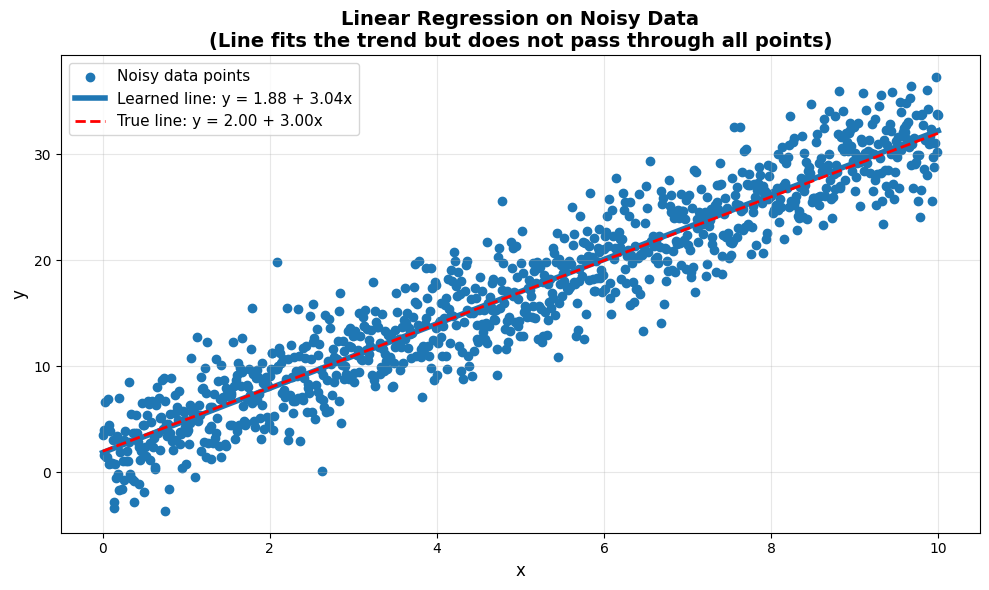

In [20]:
plt.figure(figsize=(10, 6))

# Plot noisy data points
plt.scatter(x, new_y, alpha=1.0, label="Noisy data points")

# Plot learned regression line
b0_noisy, b1_noisy = linear_regression(x, new_y)
y_noisy_pred = b0_noisy + b1_noisy * x
plt.plot(x, y_noisy_pred, linewidth=4, label=f"Learned line: y = {b0_noisy:.2f} + {b1_noisy:.2f}x")

# Plot true line (for reference)
y_true = true_b0 + true_b1 * x
plt.plot(x, y_true, color='red', linewidth=2, linestyle='--', alpha=1.0, label=f'True line: y = {true_b0:.2f} + {true_b1:.2f}x')

plt.xlabel('x', fontsize=12)
plt.ylabel('y', fontsize=12)
plt.title('Linear Regression on Noisy Data\n(Line fits the trend but does not pass through all points)', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## **Summary and Key Takeaways**

### Part 1: k-Nearest Neighbors

1. **k-NN** is a simple, instance-based classification algorithm
2. Classifies based on majority vote of k nearest neighbors
3. No training phase - just stores the data
4. Requires choosing appropriate k value
5. Feature scaling is important for distance-based methods

### Part 2: Simple Linear Regression

1. Models the relationship between one input (x) and one output (y)
2. Uses the equation: **y = b₀ + b₁·x**
3. Finds optimal parameters by minimizing Mean Squared Error
4. Perfect data → perfect fit; noisy data → approximate fit
5. MSE on noisy data approaches the variance of the noise

### Extensions to Explore

- Try different values of k for k-NN and compare performance
- Implement other distance metrics (Manhattan, Cosine)
- Extend to multiple features (multiple linear regression)
- Experiment with different noise levels
- Compare with scikit-learn implementations

### Congratulations!

You've successfully implemented two fundamental machine learning algorithms from scratch!